In [263]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tools.tools import *
from tools.bag_to_df import bag_topic_to_dataframe
import pandas as pd
from scipy.spatial.transform import Rotation as R
from tools.signal_properties import compare_signals


%load_ext autoreload
%autoreload 2

REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_12_01-09_13_39"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [264]:
print_bag_topics(REAL_BAG_PATH)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

# Read data

In [265]:
from tools.data import Nucleus

xyz_post = np.array([23.6688, 4.5, 0])
rpy_post = np.array([0, 0, -2.1])
ins_data = Nucleus(REAL_BAG_PATH, xyz_post, rpy_post)

nucleus_alitmeter = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/altimeter")
nucleus_bottomtrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/bottomtrack")
nucleus_magnetometer = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/magnetometer")
nucleus_watertrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/watertrack")


imu_sensor = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/imu")
nucleus_imu = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/imu")

# A50
dvl_a50_position = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_position")
dvl_a50_velocity = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_velocity")

# SIM
sim_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl")
sim_a50 = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl_a50")
sim_gt = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")
sim_gt_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth_dvl")
sim_ins = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ins")
sim_imu = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/imu")
print("")

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


# Normalize time

Use the first element of ground truth running at 100 Hz as the starting point of time. Topics spawn after some time

In [266]:
imu = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/imu")
t0_real = imu["t"][0]
t0_real = ins_data.df_ins["t"][0]

# Get t0 of simulation
t0_sim = sim_gt["t"].iloc[0] - 0.4
t0_sim = sim_gt["t"].iloc[0]


def set_t0(df: pd.DataFrame, t_0):
    df["t"] -= t_0

# Subtract t0
set_t0(sim_gt, t0_sim)
set_t0(sim_gt_dvl, t0_sim)
set_t0(sim_a50, t0_sim)
set_t0(sim_dvl, t0_sim)
set_t0(sim_ins, t0_sim)
set_t0(sim_imu, t0_sim)

ins_data.set_t0(t0_real)
set_t0(nucleus_alitmeter, t0_real)
set_t0(nucleus_bottomtrack, t0_real)
set_t0(nucleus_magnetometer, t0_real)
set_t0(nucleus_watertrack, t0_real)
set_t0(dvl_a50_position, t0_real)
set_t0(dvl_a50_velocity, t0_real)
set_t0(imu_sensor, t0_real)
set_t0(nucleus_imu, t0_real)


# Sway Velocity

22.571027517318726


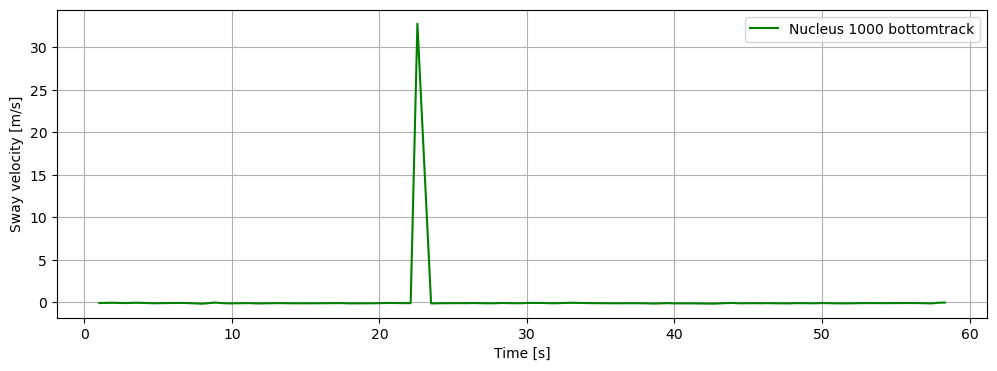

In [267]:
data = nucleus_bottomtrack.copy()

plt.figure(figsize=(12, 4))

# --- NUCLEUS BOTTOMTRACK ---
plt.plot(data["t"].values, -data["dvl_velocity_xyz.x"].values, label="Nucleus 1000 bottomtrack", color="green")

# plt.title("Sway Velocity DVL Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.legend()
plt.grid()

idx = data["dvl_velocity_xyz.x"].idxmin()

print(data["t"][idx])

Ground truth - simulated dvl:
{'rmse': 0.011986358805920054, 'corr': 0.93535137343983, 'mean1': -0.09559705061509845, 'mean2': -0.09391433376228517, 'mean_error': -0.0016827168528132993, 'var_signal1': 0.0011238501062578788, 'var_signal2': 0.0009455312617584709, 'var_difference': 0.0001783188444994079, 'var_ratio_s1_over_s2': 1.1885911674329792, 'cv_signal1': 0.3506789535921753, 'cv_signal2': 0.3274206484257331, 'kurtosis_signal1': 1.545257072765481, 'kurtosis_signal2': 0.21369665492114542, 'kurtosis_difference': 1.3315604178443357}

Ground truth - Real:
{'rmse': 0.029887693959536662, 'corr': 0.4436782539674301, 'mean1': -0.09676911960660924, 'mean2': -0.09933174387342655, 'mean_error': 0.0025626242668173064, 'var_signal1': 0.0010657297803903817, 'var_signal2': 0.0004044251974366434, 'var_difference': 0.0006613045829537384, 'var_ratio_s1_over_s2': 2.635171564841326, 'cv_signal1': 0.33735469678415636, 'cv_signal2': 0.20245618226393278, 'kurtosis_signal1': 1.538390610676812, 'kurtosis_si

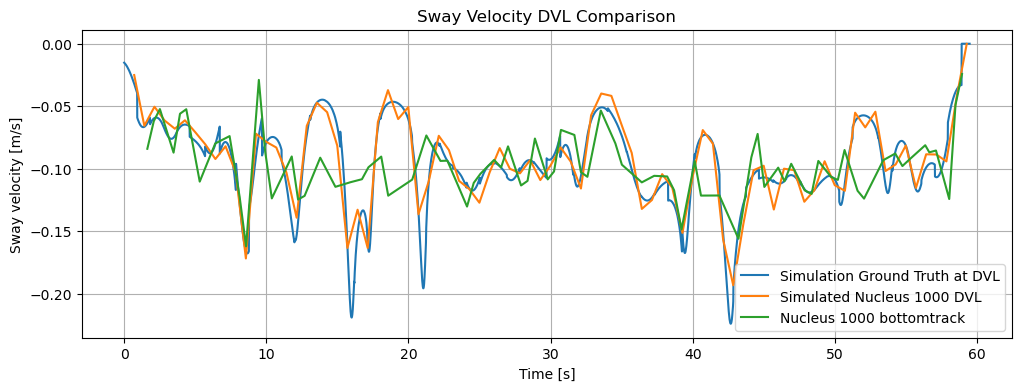

In [268]:
# Remove outlier value of dvl bottomtrack
nucleus_bottomtrack = nucleus_bottomtrack[nucleus_bottomtrack["dvl_velocity_xyz.x"] > 0]
nucleus_vel_xyz = np.array([nucleus_bottomtrack])

t_gt, data_gt = sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values
t_sim_dvl, data_sim_dvl = sim_dvl["t"].values, sim_dvl["velocity.y"].values
t_bt, data_bt = nucleus_bottomtrack["t"].values, -nucleus_bottomtrack["dvl_velocity_xyz.x"].values

# Remove lag from nucleus bottomtrack
lag_sec = get_signal_lag(t_bt, data_bt, t_gt, data_gt)
t_bt += lag_sec

plt.figure(figsize=(12, 4))

# --- GROUND THRUTH ---
plt.plot(t_gt, data_gt, label="Simulation Ground Truth at DVL")

# --- SIMULATED NUCLEUS ---
plt.plot(t_sim_dvl, data_sim_dvl, label="Simulated Nucleus 1000 DVL")

# --- NUCLEUS BOTTOMTRACK ---
plt.plot(t_bt, data_bt, label="Nucleus 1000 bottomtrack")

plt.title("Sway Velocity DVL Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.legend()
plt.grid()

comp_simulated = compare_signals(t_gt, data_gt,
                        t_sim_dvl, data_sim_dvl)

comp_real      = compare_signals(t_gt, data_gt ,
                        t_bt, data_bt)

comp_real_vs_sim = compare_signals(t_sim_dvl, data_sim_dvl,
                        t_bt, data_bt)
print("Ground truth - simulated dvl:")
print(comp_simulated)
print("\nGround truth - Real:")
print(comp_real)
print("\nSimulated - Real:")
print(comp_real_vs_sim)

Ground truth - simulated dvl:
{'rmse': 0.009099114817139372, 'corr': 0.857383957629611, 'mean1': 0.0042817314940193476, 'mean2': 0.004219647356814513, 'mean_error': 6.208413720483483e-05, 'var_signal1': 0.0002807026467312333, 'var_signal2': 0.0002987064320594054, 'var_difference': -1.8003785328172064e-05, 'var_ratio_s1_over_s2': 0.9397274936329743, 'cv_signal1': 3.91294572899135, 'cv_signal2': 4.095869674286089, 'kurtosis_signal1': 2.9671528236223033, 'kurtosis_signal2': 2.913132626836858, 'kurtosis_difference': 0.05402019678544523}

Ground truth - Real:
{'rmse': 0.01189858090773613, 'corr': 0.7809980083754713, 'mean1': 0.004317194389244338, 'mean2': 0.006493696619306049, 'mean_error': -0.0021765022300617117, 'var_signal1': 0.0002833322712802826, 'var_signal2': 0.00033454235362851694, 'var_difference': -5.1210082348234344e-05, 'var_ratio_s1_over_s2': 0.8469249654257556, 'cv_signal1': 3.8989387934055055, 'cv_signal2': 2.8166543759551126, 'kurtosis_signal1': 2.9587951327898345, 'kurtosis

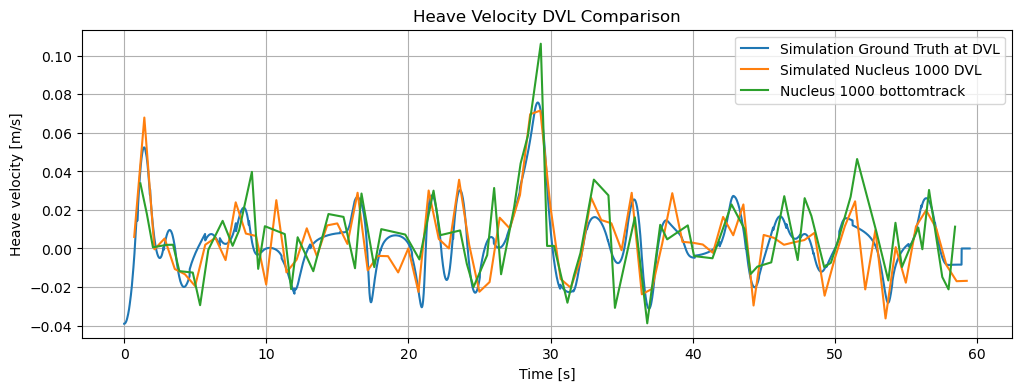

In [269]:
t_gt, data_gt = sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values
t_sim_dvl, data_sim_dvl = sim_dvl["t"].values, sim_dvl["velocity.x"].values
t_bt, data_bt = nucleus_bottomtrack["t"].values, -nucleus_bottomtrack["dvl_velocity_xyz.y"].values

lag_sec = get_signal_lag(t_bt, data_bt, t_gt, data_gt)
t_bt += lag_sec

plt.figure(figsize=(12, 4))

# --- GROUND THRUTH ---
plt.plot(t_gt, data_gt, label="Simulation Ground Truth at DVL")

# --- SIMULATED NUCLEUS ---
plt.plot(t_sim_dvl, data_sim_dvl, label="Simulated Nucleus 1000 DVL")

# --- NUCLEUS BOTTOMTRACK ---
plt.plot(t_bt, data_bt, label="Nucleus 1000 bottomtrack")

plt.title("Heave Velocity DVL Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Heave velocity [m/s]")

plt.legend()
plt.grid()

comp_simulated = compare_signals(t_gt, data_gt,
                        t_sim_dvl, data_sim_dvl)

comp_real      = compare_signals(t_gt, data_gt ,
                        t_bt, data_bt)

comp_real_vs_sim = compare_signals(t_sim_dvl, data_sim_dvl,
                        t_bt, data_bt)
print("Ground truth - simulated dvl:")
print(comp_simulated)
print("\nGround truth - Real:")
print(comp_real)
print("\nSimulated - Real:")
print(comp_real_vs_sim)

# DVL A50 velovity comparison

Simulated - Real:
{'rmse': 0.03313340414293628, 'corr': 0.4636764737731023, 'mean1': -0.09410592995095522, 'mean2': -0.09413618767602165, 'mean_error': 3.025772506643054e-05, 'var_signal1': 0.001277844537217149, 'var_signal2': 0.0006950150249884177, 'var_difference': 0.0005828295122287313, 'var_ratio_s1_over_s2': 1.8385854855993136, 'cv_signal1': 0.37985864927022756, 'cv_signal2': 0.28005316836567895, 'kurtosis_signal1': 1.0496965460500105, 'kurtosis_signal2': 1.5438677106844585, 'kurtosis_difference': -0.494171164634448}


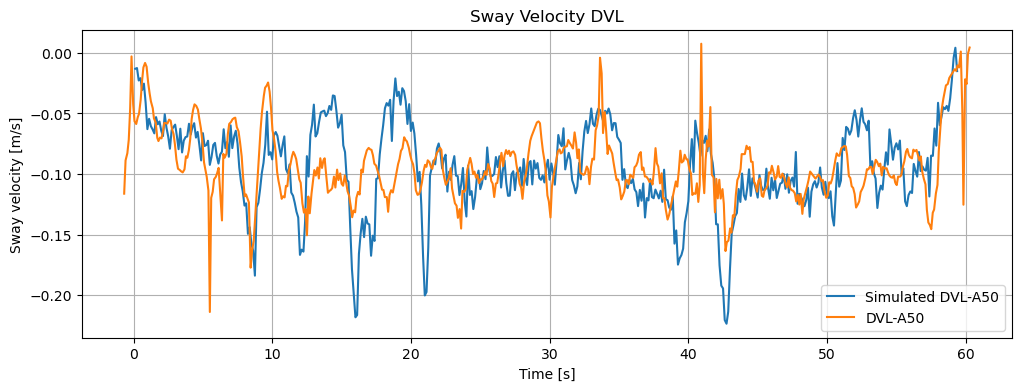

In [270]:
# Remove outlier value of dvl bottomtrack

t1, data1 = sim_a50["t"].values, sim_a50["velocity.y"].values
t2, data2 = dvl_a50_velocity["t"].values, -dvl_a50_velocity["velocity.x"].values

lag_sec = get_signal_lag(t1, data1, t2, data2)
t2 -= lag_sec

plt.figure(figsize=(12, 4))

# --- SIMULATED A50 ---
plt.plot(t1, data1, label="Simulated DVL-A50")

# --- REAL A50 ---
plt.plot(t2, data2, label="DVL-A50")


plt.title("Sway Velocity DVL")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.legend()
plt.grid()

comp_real_vs_sim = compare_signals(t1, data1,
                        t2, data2)
print("Simulated - Real:")
print(comp_real_vs_sim)

Diskusjon: Erroren vil forplante seg gjennom rekonstrueringen av signalet

# Position comparison

{'rmse': 0.007702721843138236, 'corr': 0.9959062788538237, 'mean1': 24.24425723892355, 'mean2': 24.24453306676218, 'mean_error': -0.00027582783863089945, 'var_signal1': 0.007061367926789227, 'var_signal2': 0.00721825660190473, 'var_difference': -0.00015688867511550342, 'var_ratio_s1_over_s2': 0.978265018304544, 'cv_signal1': 0.0034660556948565946, 'cv_signal2': 0.0035043085160011227, 'kurtosis_signal1': -0.8413629320898037, 'kurtosis_signal2': -0.8572704399057942, 'kurtosis_difference': 0.015907507815990485}
{'rmse': 0.012112100177512833, 'corr': 0.9999753804109396, 'mean1': -0.08365605705172538, 'mean2': -0.08132294674566333, 'mean_error': -0.002333110306062194, 'var_signal1': 2.871751450847623, 'var_signal2': 2.871627792597742, 'var_difference': 0.00012365824988114227, 'var_ratio_s1_over_s2': 1.0000430620744791, 'cv_signal1': 20.257042225818054, 'cv_signal2': 20.83775689538072, 'kurtosis_signal1': -1.219135091377622, 'kurtosis_signal2': -1.2173647512335655, 'kurtosis_difference': -0.

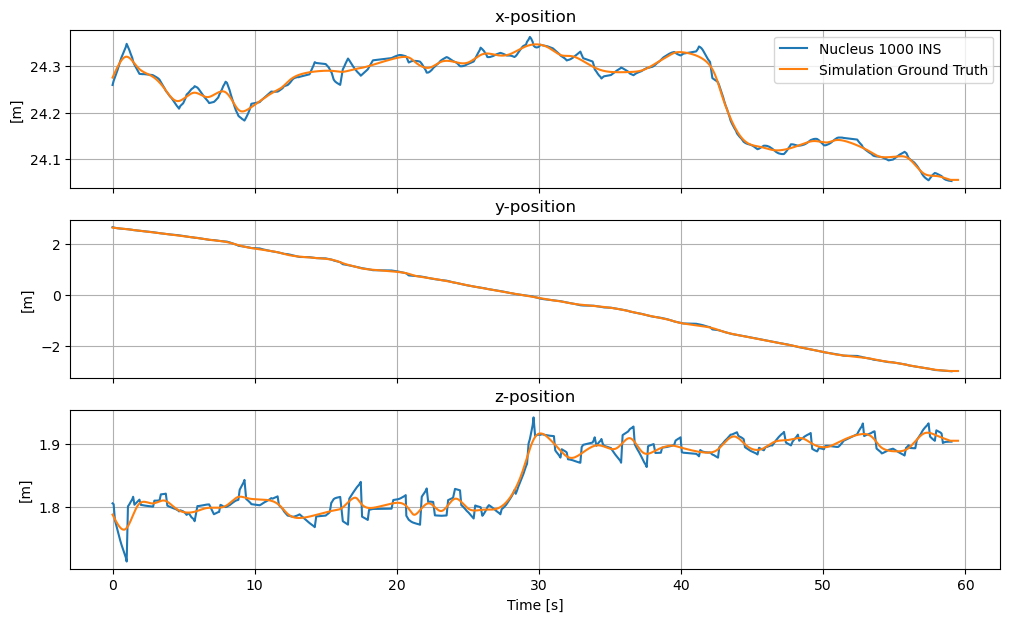

In [271]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ins_data.t, ins_data.x, label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values, label="Simulation Ground Truth")
axes[0].set_title("x-position")
axes[0].set_ylabel("[m]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ins_data.t, ins_data.y, label="Nucleus 1000 INS")
axes[1].plot(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values, label="Simulation Ground Truth")
axes[1].set_title("y-position")
axes[1].set_ylabel("[m]")
# axes[1].legend()
axes[1].grid(True)

axes[2].plot(ins_data.t, ins_data.z, label="Nucleus 1000 INS")
axes[2].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
axes[2].set_title("z-position")
axes[2].set_ylabel("[m]")
axes[2].set_xlabel("Time [s]")
# axes[2].legend()
axes[2].grid(True)

comp_x = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values,
                        ins_data.t, ins_data.x)

comp_y = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values,
                        ins_data.t, ins_data.y)

comp_z = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values,
                        ins_data.t, ins_data.z)

print(comp_x)
print(comp_y)
print(comp_z)

{'rmse': 0.01195236743149896, 'corr': 0.8566946775254309, 'mean1': 0.01017592438655573, 'mean2': 0.02042870881558717, 'mean_error': -0.01025278442903144, 'var_signal1': 7.666784803705288e-06, 'var_signal2': 6.972534230623423e-05, 'var_difference': -6.205855750252895e-05, 'var_ratio_s1_over_s2': 0.10995693316258973, 'cv_signal1': 0.27210264628056746, 'cv_signal2': 0.40874684110590265, 'kurtosis_signal1': 1.553016545253806, 'kurtosis_signal2': 4.3974791291966575, 'kurtosis_difference': -2.8444625839428515}
{'rmse': 0.008762620540065089, 'corr': 0.7530312674317943, 'mean1': -0.0034720335017445, 'mean2': -0.006705416807066483, 'mean_error': 0.003233383305321982, 'var_signal1': 6.993139631329679e-06, 'var_signal2': 9.903689200329084e-05, 'var_difference': -9.204375237196116e-05, 'var_ratio_s1_over_s2': 0.07061146094020507, 'cv_signal1': 0.761644294074063, 'cv_signal2': 1.4841326613460475, 'kurtosis_signal1': 2.7610203817801553, 'kurtosis_signal2': 1.6366176249906044, 'kurtosis_difference': 

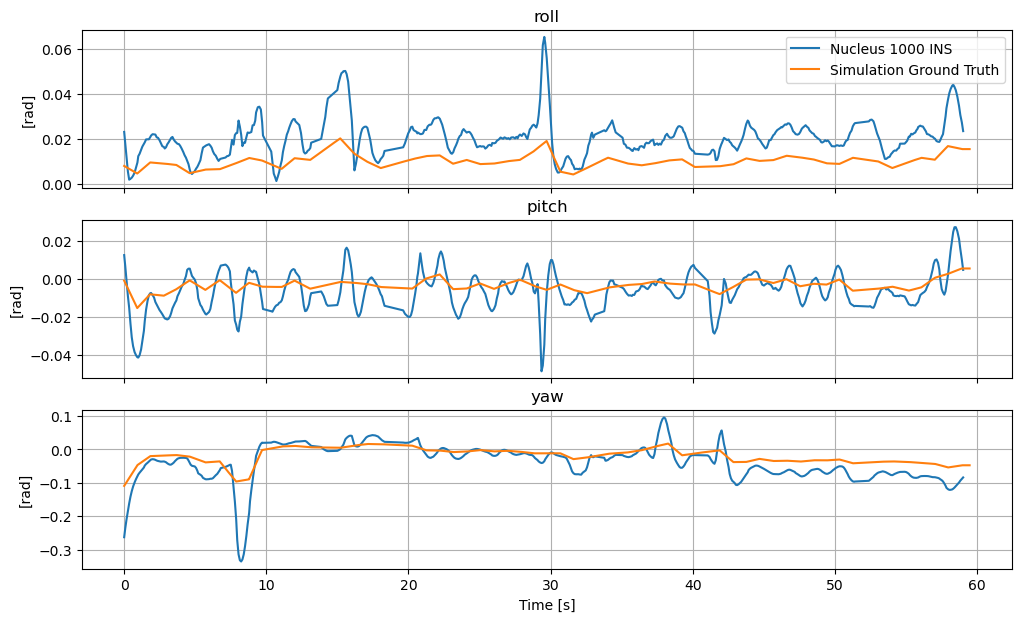

In [272]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ins_data.t, ins_data.roll, label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["pose.pose.orientation.x"].values, label="Simulation Ground Truth")
axes[0].set_title("roll")
axes[0].set_ylabel("[rad]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ins_data.t, ins_data.pitch, label="Nucleus 1000 INS")
axes[1].plot(sim_gt["t"].values, sim_gt["pose.pose.orientation.y"].values, label="Simulation Ground Truth")
axes[1].set_title("pitch")
axes[1].set_ylabel("[rad]")
# axes[1].legend()
axes[1].grid(True)

axes[2].plot(ins_data.t, ins_data.yaw, label="Nucleus 1000 INS")
axes[2].plot(sim_gt["t"].values, sim_gt["pose.pose.orientation.z"].values, label="Simulation Ground Truth")
axes[2].set_title("yaw")
axes[2].set_ylabel("[rad]")
axes[2].set_xlabel("Time [s]")
# axes[2].legend()
axes[2].grid(True)

comp_x = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.orientation.x"].values,
                        ins_data.t, ins_data.roll)

comp_y = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.orientation.y"].values,
                        ins_data.t, ins_data.pitch)

comp_z = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.orientation.z"].values,
                        ins_data.t, ins_data.yaw)

print(comp_x)
print(comp_y)
print(comp_z)

# Velocity comparison
Diskuter hvor god banen som simuleres er i forhold til ground trurth

# Velocity comparison using Nucleus frame directly

{'rmse': 0.01977051222647049, 'corr': 0.7194050151420355, 'mean1': -2.5175097989870387e-05, 'mean2': 0.0016516695739035162, 'mean_error': -0.0016768446718933867, 'var_signal1': 0.0003273974691450002, 'var_signal2': 0.0007951870464764382, 'var_difference': -0.000467789577331438, 'var_ratio_s1_over_s2': 0.41172384610103324, 'cv_signal1': 718.7311857415331, 'cv_signal2': 17.073064454086296, 'kurtosis_signal1': 4.477812903430625, 'kurtosis_signal2': -0.03803641112624989, 'kurtosis_difference': 4.515849314556874}


{'rmse': 0.033230212755594186, 'corr': 0.41721574904740044, 'mean1': -0.09512959903449349, 'mean2': -0.0969732813205994, 'mean_error': 0.001843682286105926, 'var_signal1': 0.0011403924410276446, 'var_signal2': 0.000715075887829381, 'var_difference': 0.0004253165531982636, 'var_ratio_s1_over_s2': 1.5947851975394047, 'cv_signal1': 0.35498622326806983, 'cv_signal2': 0.2757553682249589, 'kurtosis_signal1': 1.4146106965537788, 'kurtosis_signal2': 0.8323561829366932, 'kurtosis_difference': 0.5822545136170856}
{'rmse': 0.018356093919686227, 'corr': 0.5856102980960199, 'mean1': 0.003893414325493185, 'mean2': 0.004745288037435248, 'mean_error': -0.0008518737119420633, 'var_signal1': 0.0002928284462945154, 'var_signal2': 0.00048520589466685807, 'var_difference': -0.00019237744837234265, 'var_ratio_s1_over_s2': 0.6035137856178997, 'cv_signal1': 4.395173353527738, 'cv_signal2': 4.64194996665446, 'kurtosis_signal1': 2.7764898351931233, 'kurtosis_signal2': 3.4141384358880575, 'kurtosis_difference':

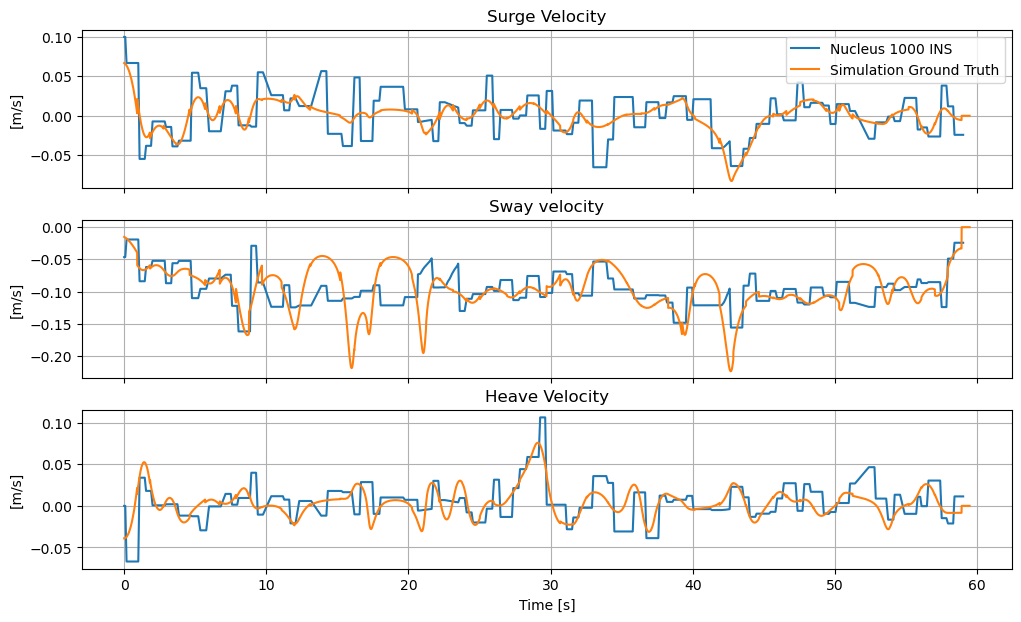

In [273]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

nucleus_ins = ins_data.df_ins

axes[0].plot(nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values, label="Nucleus 1000 INS")
axes[0].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Surge Velocity")
axes[0].set_ylabel("[m/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)
axes[1].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values)
axes[1].set_title("Sway velocity")
axes[1].set_ylabel("[m/s]")
axes[1].grid(True)


axes[2].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)
axes[2].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values)
axes[2].set_title("Heave Velocity")
axes[2].set_ylabel("[m/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_surge = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.x"].values,
                        nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values)

comp_sway = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)

comp_heave = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)

print(comp_surge)
print(comp_sway)
print(comp_heave)

# Angular velocity comparison

{'rmse': 0.027086552366075493, 'corr': -0.006925197677276746, 'mean1': 0.0002522591911052117, 'mean2': 0.0009427734601847789, 'mean_error': -0.000690514269079567, 'var_signal1': 4.121984324261019e-05, 'var_signal2': 0.0006903821348595492, 'var_difference': -0.000649162291616939, 'var_ratio_s1_over_s2': 0.0597058370448649, 'cv_signal1': 25.45107724948714, 'cv_signal2': 27.870029215610924, 'kurtosis_signal1': 4.907099096084199, 'kurtosis_signal2': 11.385322174761445, 'kurtosis_difference': -6.478223078677246}
{'rmse': 0.022965460237897938, 'corr': 0.08733375040314155, 'mean1': 0.00023227243531180828, 'mean2': 0.0006231208133672164, 'mean_error': -0.00039084837805540795, 'var_signal1': 5.7243082411815694e-05, 'var_signal2': 0.0005000972570933174, 'var_difference': -0.00044285417468150164, 'var_ratio_s1_over_s2': 0.11446389997122945, 'cv_signal1': 32.57345549483827, 'cv_signal2': 35.88847286793271, 'kurtosis_signal1': 3.3897468456244777, 'kurtosis_signal2': 9.387939927127848, 'kurtosis_dif

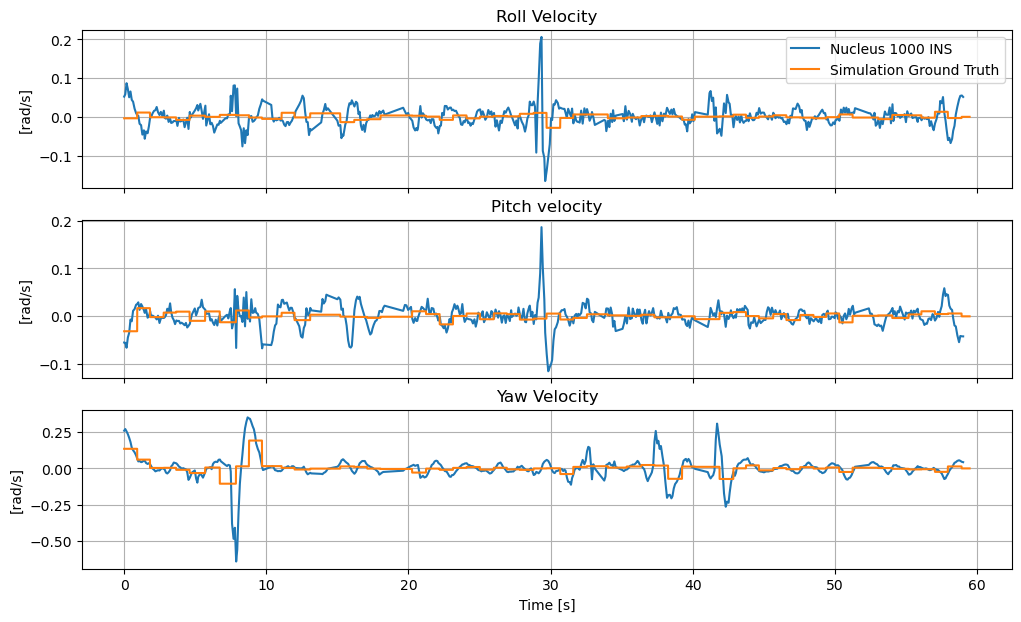

In [274]:
rpy_vel = np.column_stack((np.deg2rad(nucleus_ins["turnRate.x"].values), np.deg2rad(nucleus_ins["turnRate.z"].values), np.deg2rad(-nucleus_ins["turnRate.y"].values)))


fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ins_data.t, rpy_vel[:,0], label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Roll Velocity")
axes[0].set_ylabel("[rad/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ins_data.t, rpy_vel[:,1])
axes[1].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.y"].values)
axes[1].set_title("Pitch velocity")
axes[1].set_ylabel("[rad/s]")
axes[1].grid(True)

axes[2].plot(ins_data.t, rpy_vel[:,2])
axes[2].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.z"].values)
axes[2].set_title("Yaw Velocity")
axes[2].set_ylabel("[rad/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_roll = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.angular.x"].values,
                        ins_data.t, rpy_vel[:,0])

comp_pitch = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.angular.y"].values,
                        ins_data.t, rpy_vel[:,1])

comp_yaw = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.angular.z"].values,
                        ins_data.t, rpy_vel[:,2])

print(comp_roll)
print(comp_pitch)
print(comp_yaw)

# Beams

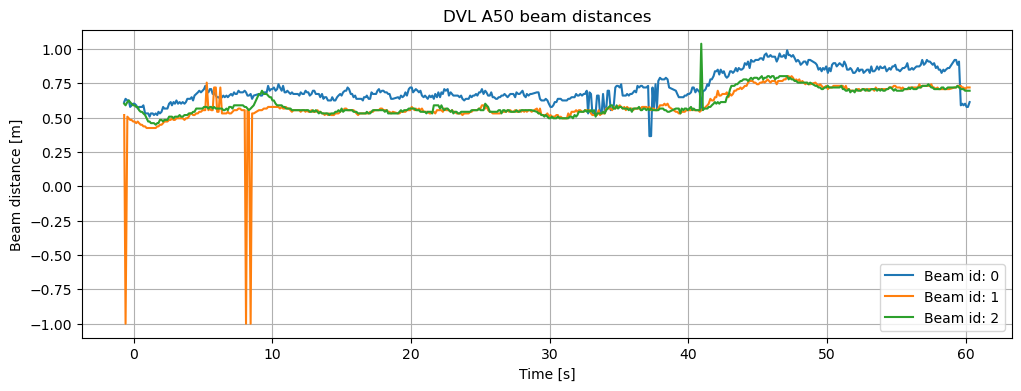

In [275]:
plt.figure(figsize=(12, 4))

# --- DVL-A50 ---
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.0.distance"].values, label="Beam id: 0")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.1.distance"].values, label="Beam id: 1")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.2.distance"].values, label="Beam id: 2")

plt.title("DVL A50 beam distances")
plt.xlabel("Time [s]")
plt.ylabel("Beam distance [m]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# INS Linear velocity 
# TODO: Fjern konstant g!

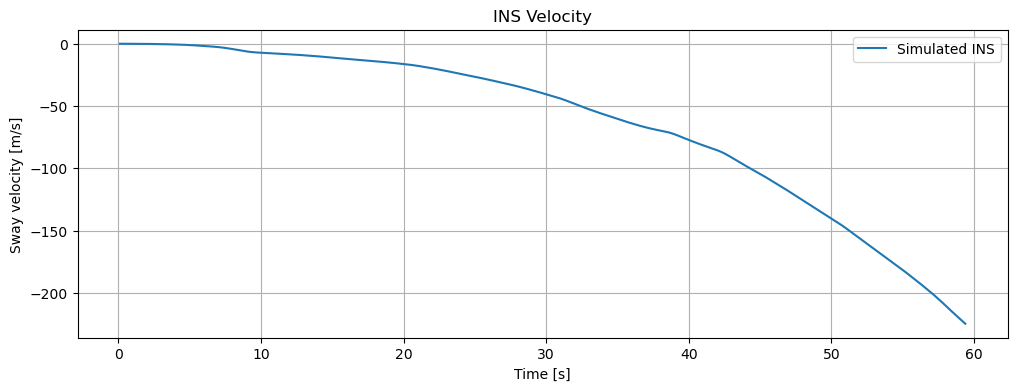

In [276]:
plt.figure(figsize=(12, 4))

plt.plot(sim_ins["t"].values, -sim_ins["pose.north"].values, label="Simulated INS")

# plt.plot(nucleus_ins["t"].values, nucleus_ins["velocityNed.x"].values, label="Nucleus 1000 INS")

# plt.plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values-0.1, label="Simulation Ground Truth")

plt.title("INS Velocity")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# Net Distance

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


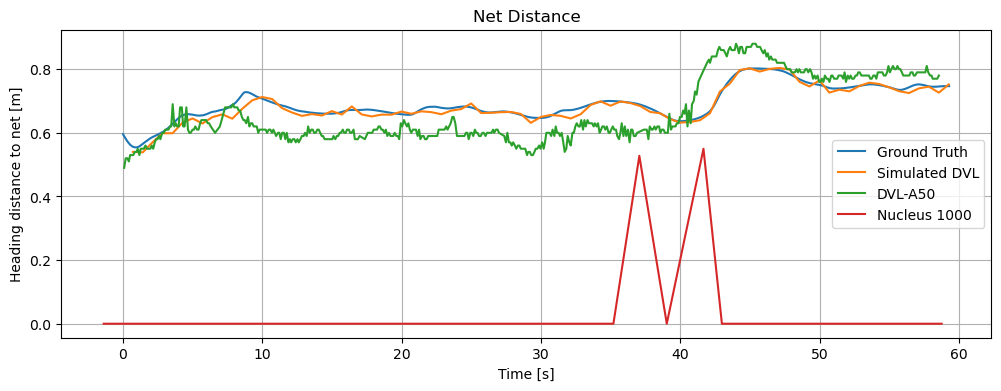

In [277]:
heading_dist_gt = get_profiler_data(SIM_BAG_PATH, "/heading_distance_ground_truth")
plane_approximation = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/navigation/plane_approximation")
normalize_time(plane_approximation)


# Remove outliers and bias
plane_approx_copy = plane_approximation.copy()
plane_approx_copy["diff"] = plane_approx_copy["NetDistance"].diff()
plane_approx_copy = plane_approx_copy[abs(plane_approx_copy["diff"]) <= 0.1]


dist_dvl_imu = 0.178

plt.figure(figsize=(12, 4))
plt.plot(heading_dist_gt["time"], np.array(heading_dist_gt["ranges"]) + dist_dvl_imu, label="Ground Truth")
plt.plot(sim_dvl["t"].values, sim_dvl["altitude"].values + dist_dvl_imu, label="Simulated DVL")
# plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["altitude"].values, label="DVL-A50 Altitude")

# plt.plot(plane_approximation["t"].values, plane_approximation["NetDistance"].values, label="Plane Approximation")
plt.plot(plane_approx_copy["t"].values, plane_approx_copy["NetDistance"].values, label="DVL-A50")


plt.plot(nucleus_alitmeter["t"].values, nucleus_alitmeter["altimeter_distance"].values, label="Nucleus 1000")


plt.title("Net Distance")
plt.xlabel("Time [s]")
plt.ylabel("Heading distance to net [m]")
plt.legend()
plt.grid()

Liten avvik i starten er mest sannsynlig på grunn av vinkelen på roven. Siden dvl har en vinkel på 4 beams.

# Pressure

In [278]:
# Read csv
real_depth_df = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/depth_temperature")
sim_depth_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/pressure")
sim_depth_gt_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")

set_t0(real_depth_df, t0_real)
set_t0(sim_depth_df, t0_sim)
set_t0(sim_depth_gt_df, t0_sim)

RHO = 1031 # [kg/m^3]
g = 9.81

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


{'rmse': 0.010933236857354055, 'corr': 0.9761586550336648, 'mean1': 1.8516110651658224, 'mean2': 1.8523826799373222, 'mean_error': -0.0007716147714999227, 'var_signal1': 0.0024759343065103344, 'var_signal2': 0.002512420336090451, 'var_difference': -3.648602958011664e-05, 'var_ratio_s1_over_s2': 0.985477736724225, 'cv_signal1': 0.026873225181657218, 'cv_signal2': 0.027059230266539832, 'kurtosis_signal1': -1.7818633083753597, 'kurtosis_signal2': -1.8193707950561417, 'kurtosis_difference': 0.037507486680782076}


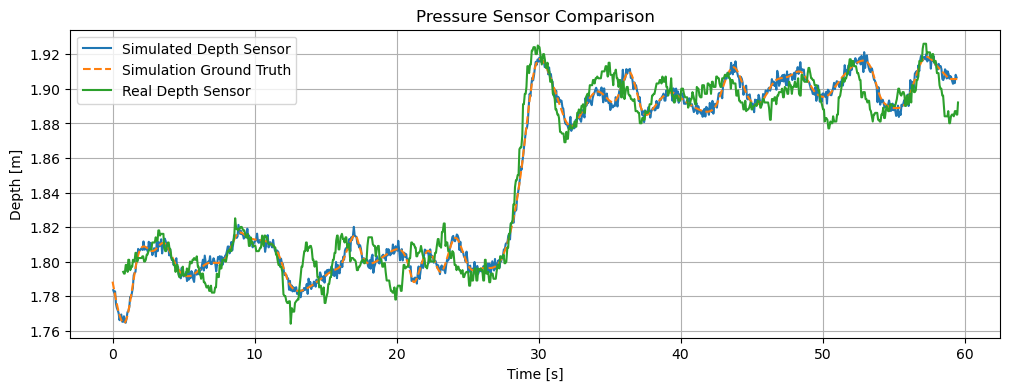

In [279]:
# Remove offset
real_depth_df["depth"] -= real_depth_df["depth"].mean()
real_depth_df["depth"] += sim_gt["pose.pose.position.z"].mean()

# get array of data
depth_real = real_depth_df["depth"].values
depth_sim = (sim_depth_df["fluid_pressure"].values) / (RHO * g)
sim_depth_gt = sim_depth_gt_df["pose.pose.position.z"].values
t_sim = sim_depth_df["t"].values
t_sim_gt = sim_depth_gt_df["t"].values
t_real = real_depth_df["t"].values

lag_sec = get_signal_lag(t_sim_gt, sim_depth_gt,
                        t_real, depth_real)

plt.figure(figsize=(12, 4))
plt.plot(t_sim, depth_sim, label="Simulated Depth Sensor")
plt.plot(t_sim_gt, sim_depth_gt, label="Simulation Ground Truth", ls="--")
plt.plot(t_real - lag_sec, depth_real, label="Real Depth Sensor")

plt.title("Pressure Sensor Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Depth [m]")
plt.legend()
plt.grid()

comp_depth = compare_signals(t_real - lag_sec, depth_real,
                        t_sim, depth_sim)

print(comp_depth)

Comparing gague pressure

In [280]:
# IMU Comparison
print_df_frequency(nucleus_imu)

Avg. frequency: 95.97 Hz


{'rmse': 0.2336213776701688, 'corr': 0.17983509147852128, 'mean1': 0.19837884430688207, 'mean2': 0.02228840213198376, 'mean_error': 0.17609044217489833, 'var_signal1': 0.02031173165180612, 'var_signal2': 0.00781425596825812, 'var_difference': 0.012497475683547999, 'var_ratio_s1_over_s2': 2.5993174186145604, 'cv_signal1': 0.7184195122522782, 'cv_signal2': 3.9661111560740134, 'kurtosis_signal1': 9.348679736759985, 'kurtosis_signal2': 1.6968831853312132, 'kurtosis_difference': 7.651796551428772}
{'rmse': 0.8333134971795824, 'corr': -0.06204425709095146, 'mean1': -0.07042792429695166, 'mean2': 0.747568488252423, 'mean_error': -0.8179964125493747, 'var_signal1': 0.015963852155057932, 'var_signal2': 0.007956245642998521, 'var_difference': 0.008007606512059411, 'var_ratio_s1_over_s2': 2.006455415200269, 'cv_signal1': 1.79400628329739, 'cv_signal2': 0.1193172142124616, 'kurtosis_signal1': 2.045935489563563, 'kurtosis_signal2': 2.6668736174885694, 'kurtosis_difference': -0.6209381279250064}
{'r

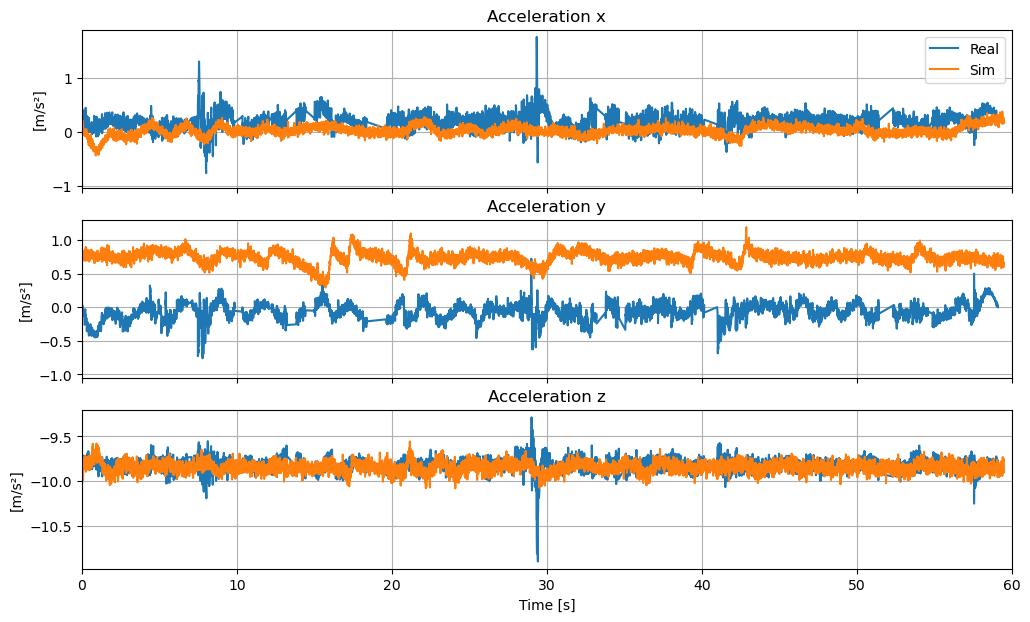

In [281]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.x"].values, label="Real")
axes[0].plot(sim_imu["t"].values, sim_imu["linear_acceleration.x"].values, label="Sim")
axes[0].set_title("Acceleration x")
axes[0].set_ylabel("[m/s²]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.z"].values, label="Real")
axes[1].plot(sim_imu["t"].values, sim_imu["linear_acceleration.y"].values, label="Sim")
axes[1].set_title("Acceleration y")
axes[1].set_ylabel("[m/s²]")
axes[1].grid(True)

axes[2].plot(nucleus_imu["t"].values, -nucleus_imu["accelerometer.y"].values, label="Real")
axes[2].plot(sim_imu["t"].values, sim_imu["linear_acceleration.z"].values, label="Sim")
axes[2].set_title("Acceleration z")
axes[2].set_ylabel("[m/s²]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

axes[0].set_xlim((0, 60))


acc_x = compare_signals(nucleus_imu["t"].values, nucleus_imu["accelerometer.x"].values,
                        sim_imu["t"].values, sim_imu["linear_acceleration.x"].values)

acc_y = compare_signals(nucleus_imu["t"].values, nucleus_imu["accelerometer.z"].values,
                        sim_imu["t"].values, sim_imu["linear_acceleration.y"].values)

acc_z = compare_signals(nucleus_imu["t"].values, -nucleus_imu["accelerometer.y"].values,
                        sim_imu["t"].values, sim_imu["linear_acceleration.z"].values)

print(acc_x)
print(acc_y)
print(acc_z)

Simulerer ikke dorpouts

(0.0, 60.0)

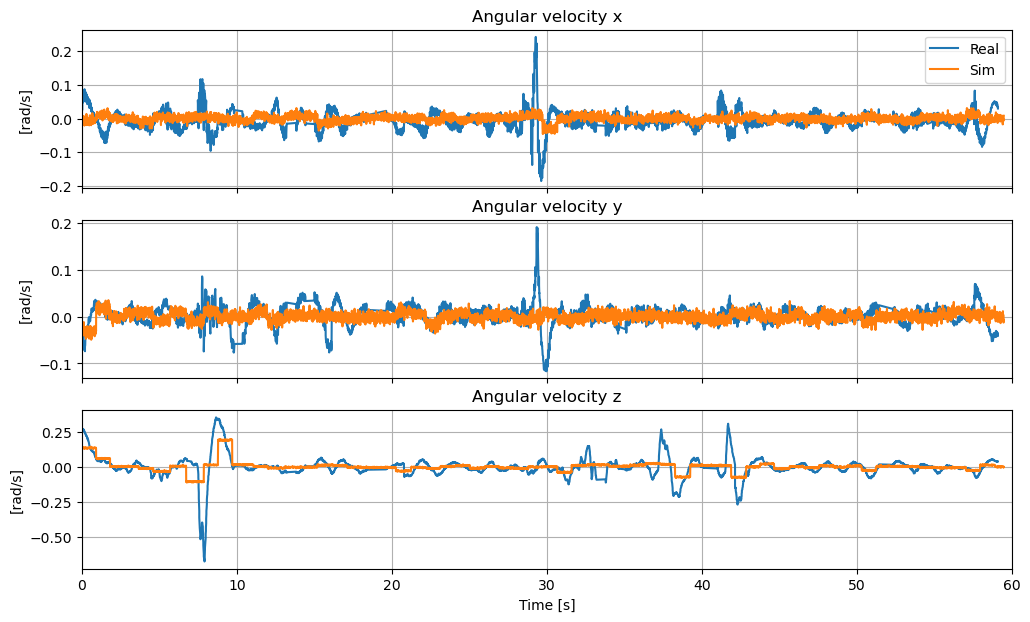

In [282]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(nucleus_imu["t"].values, nucleus_imu["gyroscope.x"].values, label="Real")
axes[0].plot(sim_imu["t"].values, sim_imu["angular_velocity.x"].values, label="Sim")
axes[0].set_title("Angular velocity x")
axes[0].set_ylabel("[rad/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_imu["t"].values, nucleus_imu["gyroscope.z"].values, label="Real")
axes[1].plot(sim_imu["t"].values, sim_imu["angular_velocity.y"].values, label="Sim")
axes[1].set_title("Angular velocity y")
axes[1].set_ylabel("[rad/s]")
axes[1].grid(True)

axes[2].plot(nucleus_imu["t"].values, -nucleus_imu["gyroscope.y"].values, label="Real")
axes[2].plot(sim_imu["t"].values, sim_imu["angular_velocity.z"].values, label="Sim")
axes[2].set_title("Angular velocity z")
axes[2].set_ylabel("[rad/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

axes[0].set_xlim((0, 60))

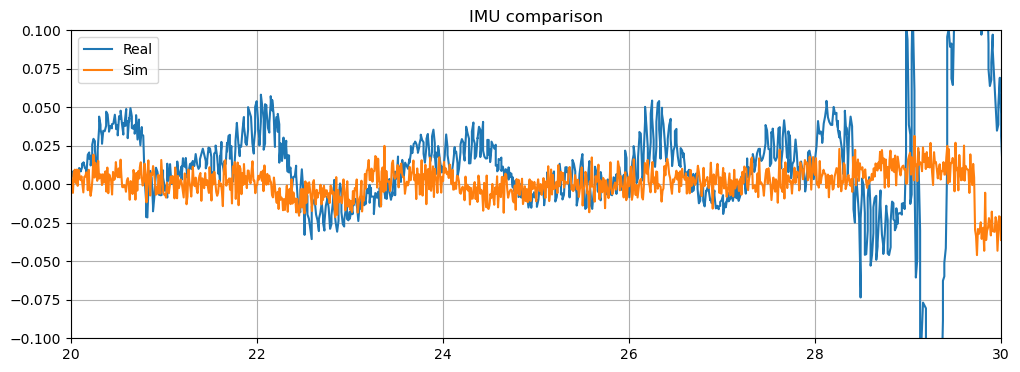

In [283]:
# IMU Comparison
plt.figure(figsize=(12, 4))



plt.plot(nucleus_imu["t"].values, -nucleus_imu["gyroscope.x"].values, label="Real")
plt.plot(sim_imu["t"].values, sim_imu["angular_velocity.x"].values, label="Sim")

plt.legend()


plt.title("IMU comparison")

plt.xlim((20, 30))
plt.ylim((-0.1, 0.1))

plt.legend()
plt.grid()